# Evaluate Models

Este notebook se realiza la evaluación de los modelos candidatos que previuamente se entrenaron

## Imports y configuración

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

ROOT_DIR = Path.cwd().parent if (Path.cwd().name == "03_model_selection") else Path.cwd()
sys.path.insert(0, str(ROOT_DIR))

from src.models.model_evaluation import (
    load_all_model_artifacts,
    evaluate_fitted_models,
    extract_fraud_probabilities,
    extract_feature_importance,
    summarize_pr_curve,
    sweep_business_profit,
    summarize_confusion_matrix,
    sweep_fbeta_score,
    build_threshold_report,
    show_threshold_report,
    plot_precision_recall,
    plot_business_profit,
    plot_confusion_heatmap,
    plot_fbeta_curve,
    plot_feature_importance,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

DATASET_DIR = ROOT_DIR / "dataset"
TEST_PATH = DATASET_DIR / "test.csv"
ARTIFACTS_DIR = ROOT_DIR / "03_model_selection" / "artifacts"

TARGET_COL = "fraude"
# "k" es el identificador 100% único de cada transacción: se excluye igual que en
# 00_train_models.ipynb, ya que los Pipeline guardados se entrenaron sin esa columna.
ID_COL = "k"

# Threshold de decisión para Precision/Recall/J/matriz de confusión/classification report.
DECISION_THRESHOLD = 0.5

## Carga de datos de test

Solo se necesita `test.csv` — los `Pipeline` cargados ya están ajustados (incluyen el preprocesamiento aprendido en train), así que no se toca `train.csv` en este notebook.

In [2]:
test_df = pd.read_csv(TEST_PATH)
test_df["fecha"] = pd.to_datetime(test_df["fecha"])

X_test = test_df.drop(columns=[TARGET_COL, ID_COL])
y_test = test_df[TARGET_COL]
monto_test = test_df["monto"].to_numpy()

print(f"X_test: {X_test.shape} | y_test: {y_test.shape} | tasa fraude: {y_test.mean():.4f}")
X_test.head()

X_test: (45019, 17) | y_test: (45019,) | tasa fraude: 0.0457


,a,b,c,d,e,f,g,h,j,l,m,n,o,p,fecha,monto,score
0,4,0.7858,842559.99,2.0,0.000000,13.0,AR,4,cat_bfa223b,3124.0,341.0,1,NaN,Y,2020-04-10 00:00:21,94.52,34
1,4,0.6950,313868.27,2.0,0.183543,0.0,BR,56,cat_b23deda,551.0,37.0,1,N,N,2020-04-10 00:00:35,9.25,79
2,4,0.8351,90720.67,6.0,0.619592,5.0,BR,6,cat_0820fab,165.0,101.0,1,NaN,Y,2020-04-10 00:00:40,5.51,61
3,1,0.8049,622853.97,50.0,0.222066,4.0,BR,14,cat_20ab7f2,892.0,341.0,1,NaN,Y,2020-04-10 00:00:50,23.09,25
4,4,0.6943,82004.30,50.0,1.639311,1.0,AR,4,cat_6044b45,1402.0,347.0,1,NaN,Y,2020-04-10 00:02:38,4.73,54


## Read artifacts models

En este apartado se realiza la lectura de lso artifacts de cada modelo

In [3]:
fitted_pipelines = load_all_model_artifacts(ARTIFACTS_DIR)

print(f"Modelos cargados desde {ARTIFACTS_DIR}:")
for name in fitted_pipelines:
    print(f" - {name}")

Modelos cargados desde /Users/dpiedrahita/proyectos/DS_pro/03_model_selection/artifacts:
 - CatBoost
 - LightGBM
 - LogisticRegression
 - RandomForest
 - XGBoost


## Tabla comparativa de métricas

A continuación se evaluan los modelos, teniendo en cuenta las siguientes metricas:

- AUC
- PR-AUC
- Recall
- Peecision
- J

In [4]:
results_df = evaluate_fitted_models(fitted_pipelines, X_test, y_test, monto=monto_test, threshold=DECISION_THRESHOLD)
results_df

/Users/dpiedrahita/proyectos/DS_pro/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,AUC,PR-AUC,Precision (TH fijo),Recall (TH fijo),J ($),J ($) block all,TH óptimo,Precision (TH óptimo),Recall (TH óptimo),J óptimo ($)
modelo,,,,,,,,,,
CatBoost,0.8805,0.4368,0.3045,0.5758,-91003.7225,-428970.0425,0.5418,0.3383,0.5418,-87886.9525
LightGBM,0.8850,0.4354,0.2806,0.6156,-91519.2750,-428970.0425,0.6120,0.3702,0.5005,-86068.1375
LogisticRegression,0.7525,0.1907,0.1065,0.6691,-210733.2775,-428970.0425,0.7525,0.3143,0.1788,-127170.6825
RandomForest,0.8673,0.4049,0.5374,0.3421,-105370.8000,-428970.0425,0.3010,0.3452,0.4985,-93752.2425
XGBoost,0.8681,0.4203,0.3548,0.4879,-91423.7725,-428970.0425,0.5619,0.3956,0.4495,-90194.0975


Como se puede observar en la tabla anterior los mejor

## Classification report y gráficos por modelo

A continuación, se obtienen las metricas de cada modelo y sus respectivos graficos, en lso cuales podemos observar:

- Classification report
- Pecision - Recall Curve
- Confusion Matrix Heatmap
- Impacvto funcion de ganancia 
- Feature Importance


CatBoost

CatBoost — Classification Report (threshold = 0.5418)
──────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

           0     0.9774    0.9492    0.9631     42961
           1     0.3383    0.5418    0.4165      2058

    accuracy                         0.9306     45019
   macro avg     0.6578    0.7455    0.6898     45019
weighted avg     0.9482    0.9306    0.9381     45019

Mejor threshold por J: 0.5418 -> J = -87,886.95
  TP=1115  FP=2181  FN=943  TN=40780  |  Precision=0.3383  Recall=0.5418


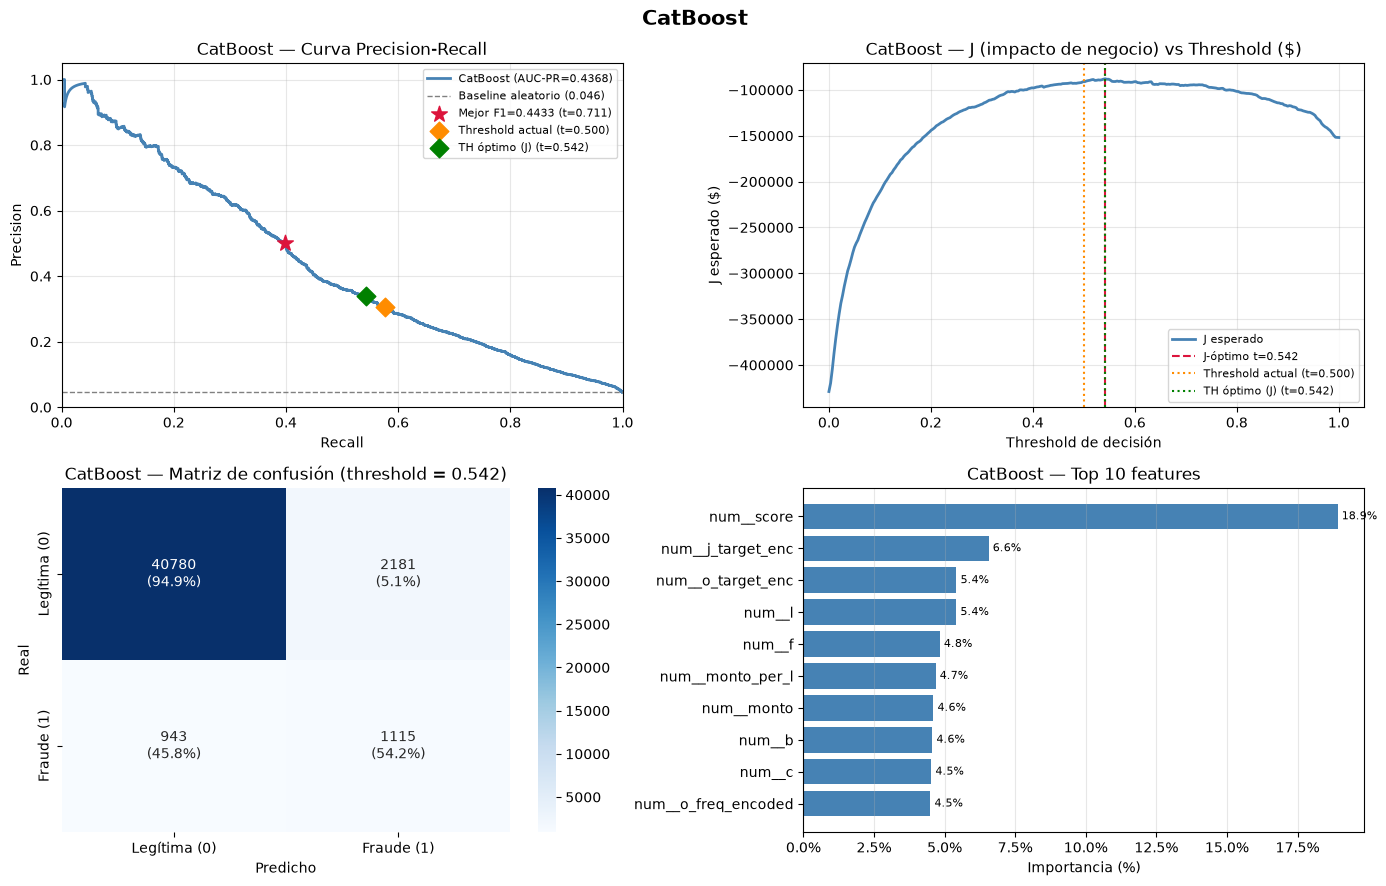


LightGBM


/Users/dpiedrahita/proyectos/DS_pro/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



LightGBM — Classification Report (threshold = 0.6120)
──────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

           0     0.9757    0.9592    0.9674     42961
           1     0.3702    0.5005    0.4256      2058

    accuracy                         0.9382     45019
   macro avg     0.6729    0.7299    0.6965     45019
weighted avg     0.9480    0.9382    0.9426     45019

Mejor threshold por J: 0.6120 -> J = -86,068.14
  TP=1030  FP=1752  FN=1028  TN=41209  |  Precision=0.3702  Recall=0.5005


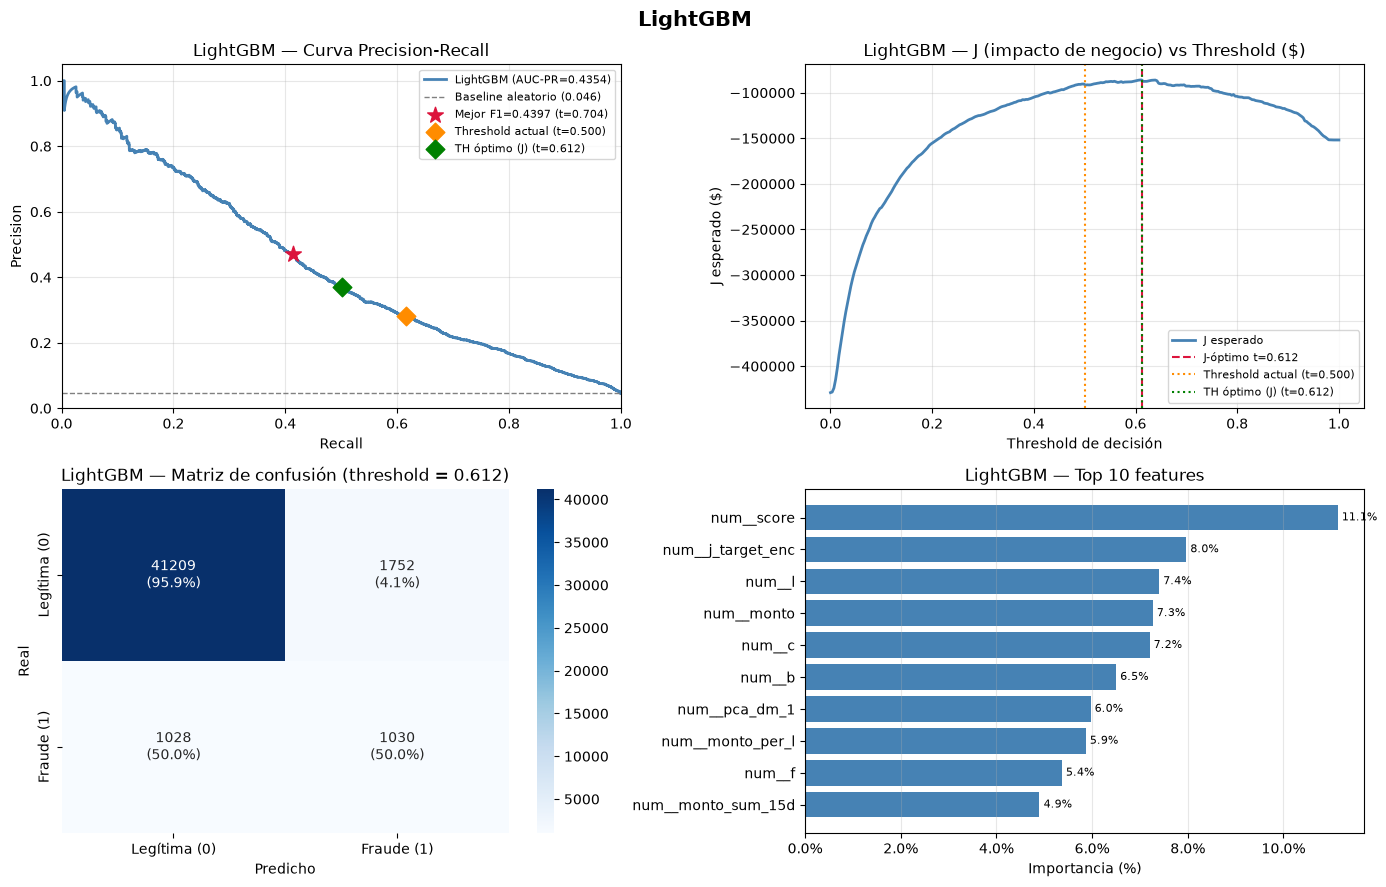


LogisticRegression

LogisticRegression — Classification Report (threshold = 0.7525)
──────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

           0     0.9615    0.9813    0.9713     42961
           1     0.3143    0.1788    0.2279      2058

    accuracy                         0.9446     45019
   macro avg     0.6379    0.5801    0.5996     45019
weighted avg     0.9319    0.9446    0.9373     45019

Mejor threshold por J: 0.7525 -> J = -127,170.68
  TP=368  FP=803  FN=1690  TN=42158  |  Precision=0.3143  Recall=0.1788


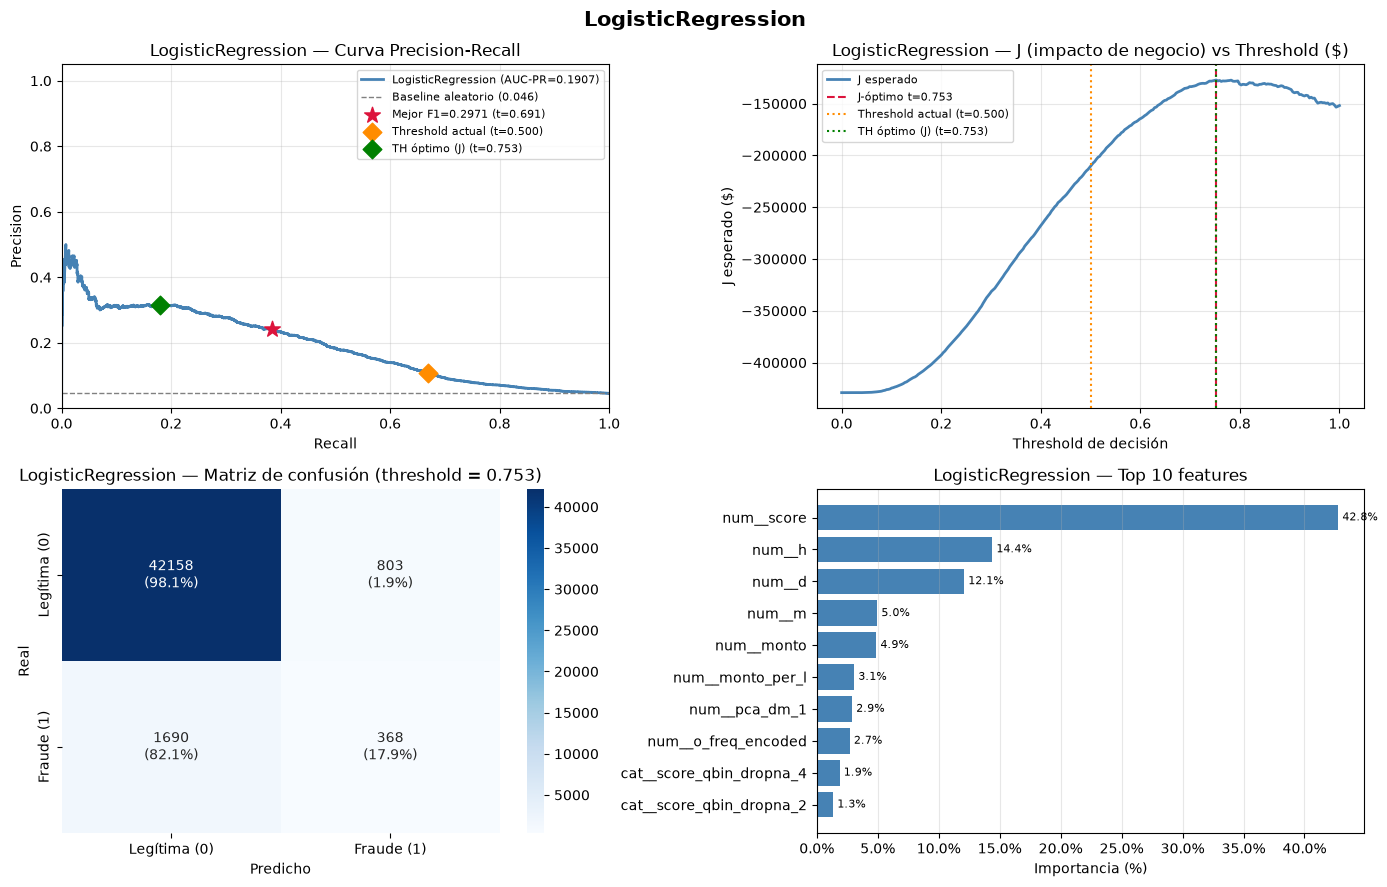


RandomForest

RandomForest — Classification Report (threshold = 0.3010)
──────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

           0     0.9755    0.9547    0.9650     42961
           1     0.3452    0.4985    0.4080      2058

    accuracy                         0.9339     45019
   macro avg     0.6603    0.7266    0.6865     45019
weighted avg     0.9466    0.9339    0.9395     45019

Mejor threshold por J: 0.3010 -> J = -93,752.24
  TP=1026  FP=1946  FN=1032  TN=41015  |  Precision=0.3452  Recall=0.4985


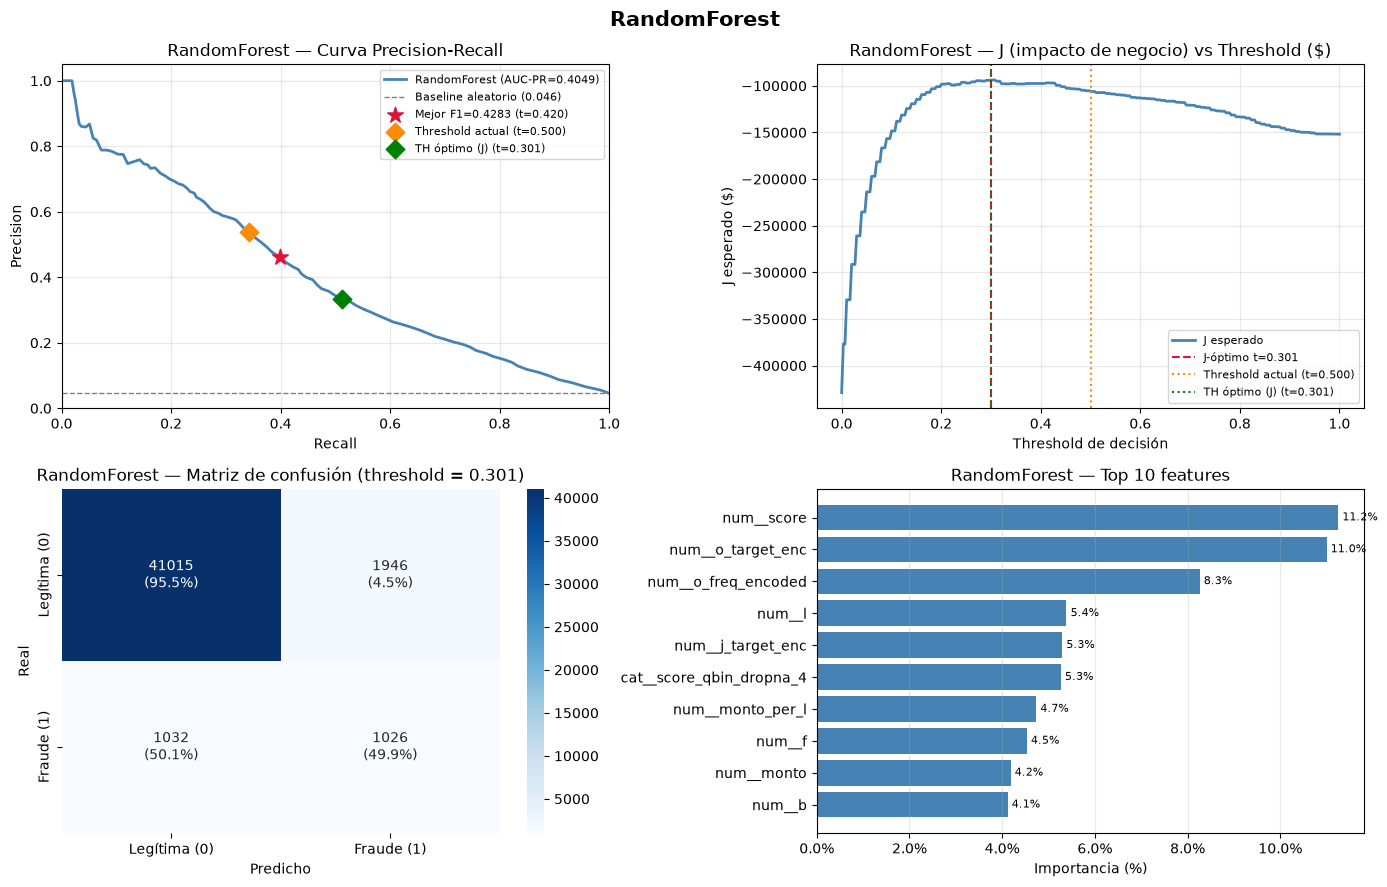


XGBoost

XGBoost — Classification Report (threshold = 0.5619)
──────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

           0     0.9735    0.9671    0.9703     42961
           1     0.3956    0.4495    0.4208      2058

    accuracy                         0.9434     45019
   macro avg     0.6845    0.7083    0.6956     45019
weighted avg     0.9470    0.9434    0.9452     45019

Mejor threshold por J: 0.5619 -> J = -90,194.10
  TP=925  FP=1413  FN=1133  TN=41548  |  Precision=0.3956  Recall=0.4495


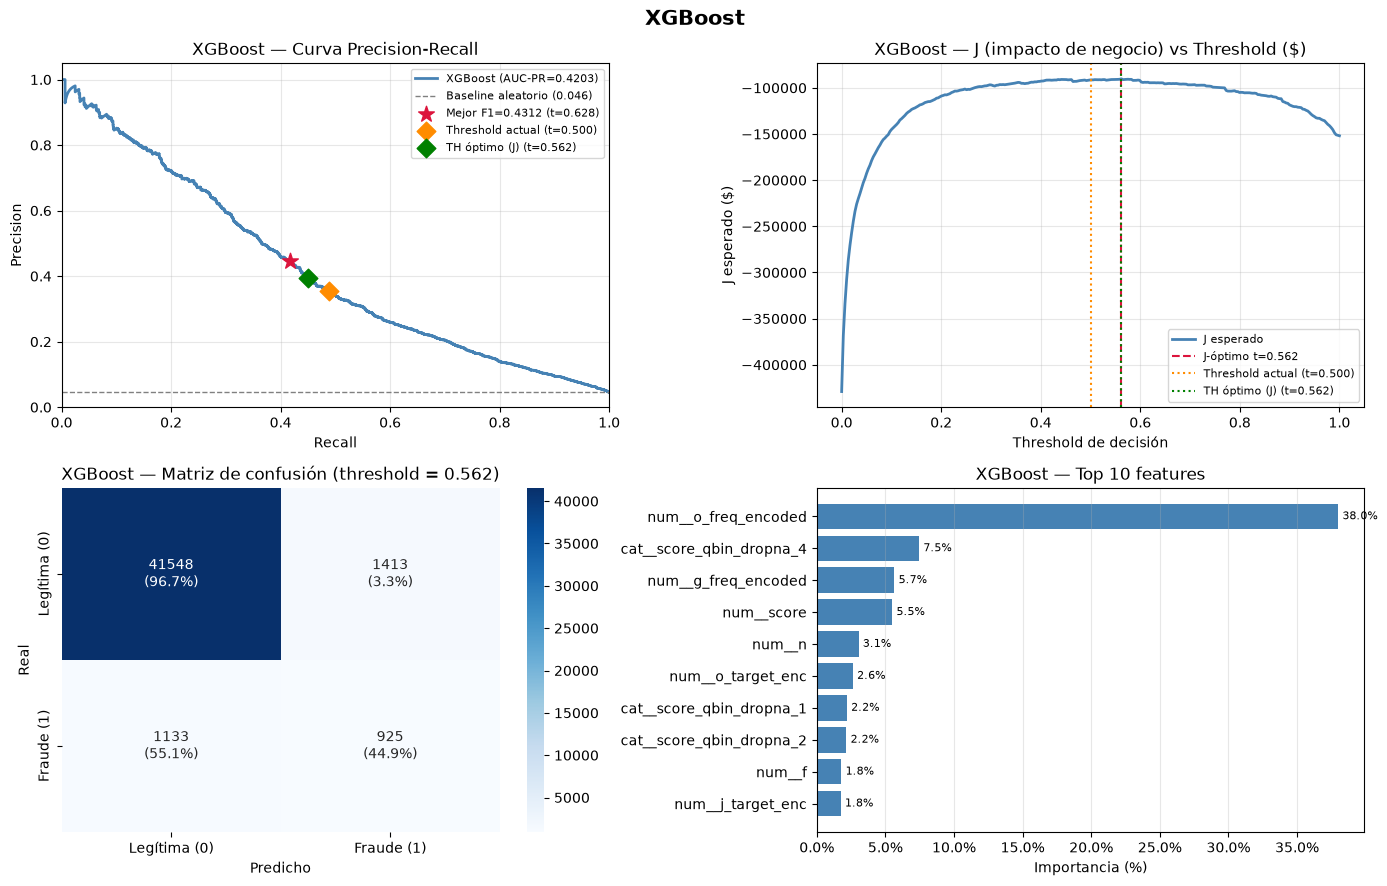

In [5]:
for name, pipe in fitted_pipelines.items():

    print(f"\n{'=' * 90}\n{name}\n{'=' * 90}")

    scores = extract_fraud_probabilities(pipe, X_test)

    pr_stats = summarize_pr_curve(y_test, scores)
    profit_stats = sweep_business_profit(y_test, scores, monto=monto_test)

    report_stats = build_threshold_report(y_test, scores, threshold=profit_stats["best_j_threshold"])
    show_threshold_report(report_stats, model_name=name)

    cm_stats = summarize_confusion_matrix(y_test, scores, threshold=profit_stats["best_j_threshold"])
    importance_df = extract_feature_importance(pipe, top_n=10)

    highlights = [
        (DECISION_THRESHOLD, "Threshold actual"),
        (profit_stats["best_j_threshold"], "TH óptimo (J)"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    plot_precision_recall(pr_stats, model_name=name, highlight_thresholds=highlights, ax=axes[0, 0])
    plot_business_profit(profit_stats, model_name=name, highlight_thresholds=highlights, ax=axes[0, 1])
    plot_confusion_heatmap(cm_stats, model_name=name, ax=axes[1, 0])
    plot_feature_importance(importance_df, model_name=name, ax=axes[1, 1])

    fig.suptitle(name, fontsize=15, fontweight="bold")
    fig.tight_layout()
    plt.show()

## Resumen por modelo

Como referencia de piso: rechazar todas las transacciones (`J ($) block all`) cuesta **-$428,970.04** (se pierde el 25% de margen de todas las transacciones legítimas). Todos los modelos mejoran sustancialmente ese escenario.

La tabla comparativa y el classification report de cada modelo ahora contrastan dos puntos de operación:
- **TH fijo (0.5)**: el umbral por defecto de cualquier clasificador binario.
- **TH óptimo (J)**: el umbral que maximiza la métrica de negocio real, específico de cada modelo, mientras mas cercano a cero mayor será la ganancia objetivo

Comparar ambos deja ver **cuánto valor deja en la mesa cada modelo si se usa sin calibrar el threshold**:

| Modelo | J (TH fijo) | J (TH óptimo) | Ganancia por calibrar | % ganancia |
|---|---|---|---|---|
| LogisticRegression | -$210,733 | -$127,171 | +$83,563 | **39.6%** |
| RandomForest | -$105,371 | -$93,752 | +$11,619 | 11.0% |
| LightGBM | -$91,519 | -$86,068 | +$5,451 | 6.0% |
| CatBoost | -$91,004 | -$87,887 | +$3,117 | 3.4% |
| XGBoost | -$91,424 | -$90,194 | +$1,230 | 1.3% |

### CatBoost

- **Impacto de negocio**: $J$ óptima de **-$87,887** en threshold **0.542** (Precision 0.3383 / Recall 0.5418), 2do mejor resultado, prácticamente empatado con LightGBM (diferencia de ~$1,819, <1% del total). Mejor **PR-AUC** del grupo (0.4368). Solo gana **3.4%** al calibrar el threshold desde 0.5, ya viene razonablemente bien calibrado por defecto.
- **Fortalezas**: importancia repartida sin depender solo de variables numéricas, combina bien la señal del score externo con las categóricas de alta cardinalidad (`j`, `o`) que el EDA marcó como más discriminantes. Coherente con su fama de "funciona bien out-of-the-box con categóricas".
- **Limitaciones y riesgos**: observando el feature importance el modelo depende en gran medida de una sola variable (`score`: 18%) y luego da un salto a la siguiente variable (`j_target_enc`: 8%), lo cual desequilibra la decisión y gran parte depende solo de la variable más importante.

### LightGBM

- **Impacto de negocio**: **mejor $J$ óptima del grupo, -$86,068**, en threshold **0.612** (Precision 0.3702 / Recall 0.5005). Al subir el threshold desde 0.5, gana Precision (0.2806→0.3702) a costa de Recall (0.6156→0.5005), y aun así mejora $J$ en **6.0%** — el mejor resultado neto de todos, aunque no el que más se beneficia de calibrar.
- **Fortalezas**: la importancia es la más **repartida** de los 5 modelos (top-5 features acumulan ~41%), utiliza `score`, `j_target_enc`, `l`, `monto`, `c` de forma más pareja, lo que en principio lo hace menos dependiente de que una sola variable se mantenga estable en producción.
- **Limitaciones**: en comparación al modelo CatBoost este tiene un recall ligeramente menos, esto implica que deja pasar mas fraude.

### XGBoost

- **Impacto de negocio**: $J$ óptima de **-$90,194** en threshold **0.562** (Precision 0.3956 / Recall 0.4495), 3er lugar. Es el modelo que **menos se beneficia de calibrar el threshold** (solo +1.3%, la ganancia más chica del grupo): a 0.5 ya está casi en su óptimo, señal de que sus probabilidades ya vienen razonablemente bien calibradas para esta función de costo.
- **Fortalezas**: mejor **Precision al threshold óptimo** entre los 3 boosting (0.3956), de los árboles, el que menos falsos positivos genera en su punto de operación.
- **Limitaciones**: **altísima concentración en una sola variable** `o_freq_encoded` explica **38.0%** de su importancia total, muy por encima del resto (siguiente feature al 7.5%). Riesgo de negocio: si el patrón de nulos/frecuencia de `o` cambia en producción (concept drift), este modelo es el más expuesto a degradarse silenciosamente, ya que depende desproporcionadamente de una única señal.

### Random Forest

- **Impacto de negocio**: peor $J$ óptima entre los árboles (**-$93,752**), pero es el que **más se beneficia de calibrar el threshold entre los no lineales** (+11.0%, solo por debajo de la Logística)
- **Fortalezas**: mayor **Precision** de los 5 modelos a TH fijo (0.5374), cuando marca fraude a 0.5, acierta más que los demás; útil como "sanity check" no lineal y el más simple/difícil de sobreajustar del grupo. Importancia razonablemente repartida (`score` 11.2%, `o_target_enc` 11.0%, `o_freq_encoded` 8.3%, `l` 5.4%, `j_target_enc` 5.3%).
- **Limitaciones**: puede llegar a ser el modelo ams lento en responder, entre los modelos de arboles en comapración es el que peor $J$ óptima tiene.

### Logistic Regression (baseline)

- **Impacto de negocio**: **peor resultado del grupo en ambos puntos**, pero también el que **más se beneficia de calibrar el threshold, por lejos** (+39.6%, de -$210,733 a -$127,171). Su threshold óptimo (**0.7525**) es muy alto: ahí su Recall se desploma (0.6691→0.1788) pero la Precision mejora (0.1065→0.3143) lo suficiente para que el neto en $J$ mejore mucho, aun así, sigue siendo ~45% peor que LightGBM en su mejor punto. Menor AUC (0.7525) y PR-AUC (0.1907, la única por debajo de 0.2).
- **Fortalezas**: interpretabilidad total (`|coef_|`) y velocidad de entrenamiento, cumple su rol de piso de comparación: confirma que los modelos de árboles capturan relaciones no lineales reales, no solo ruido. También deja una lección operativa clara: **calibrar el threshold es más crítico cuanto más simple/mal calibrado es el modelo**.
- **Limitaciones**: importancia **muy concentrada en 3 variables numéricas** (`score` 42.8%, `h` 14.4%, `d` 12.1% → ~69% acumulado) y **no aparece ninguna categórica codificada** en su top 5, no logra explotar `o_target_enc`/`j_target_enc`, que el EDA y los demás modelos identifican como señales fuertes. Es la confirmación más clara de que la relación entre las features y el fraude no es lineal.

## Conclusión

Por impacto de negocio ($J$ óptima), el orden es **LightGBM ≈ CatBoost > XGBoost > RandomForest >> LogisticRegression**, con LightGBM y CatBoost prácticamente empatados (<1% de diferencia) y muy por delante de la Logística. La elección entre LightGBM y CatBoost pasa por otros criterios no capturados en estas métricas:

- LightGBM es más rápido de entrenar/servir pero más sensible al threshold y al riesgo de overfitting
- CatBoost ofrece una mayor captura de fraude con menor falsos negativos, sin embargo, este concentra mucho de su fetaure importance en una sola variable, si hay drift severo en esa feature, el modelo puede degradarse considerablemente.
- **XGBoost queda como alternativa válida pero con mayor riesgo de concept drift** por su dependencia extrema de `o_freq_encoded` similar al CatBoost pero no tan severo.

## Next Steps

- Realizar procesos de Hypertuninh de paramametros y validación cruzada
- Realizar comparación cons otros tipos de modelos (Basados en árboles VS Redes neuronales)
- Implementar herramientas como MLFlow que permitan llevar un historial del tracking de los modelos